In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

# Module 5：非監督式學習：降維與分群

## 資料欄位說明

| 欄位 | 說明 |
|---|---|
| Number | 寶可夢編號 |
| Name | 寶可夢名稱 |
| Type1 | 第一屬性 |
| Type2 | 第二屬性，若沒有第二屬性則為空值 |
| HP | 生命值 |
| Attack | 物理攻擊 |
| Defense | 物理防禦 |
| SpecialAtk | 特殊攻擊 |
| SpecialDef | 特殊防禦 |
| Speed | 速度 |
| Generation | 世代 |
| Legendary | 是否為傳奇寶可夢 |

本章主要使用六個數值型能力值欄位：

`HP`, `Attack`, `Defense`, `SpecialAtk`, `SpecialDef`, `Speed`

In [2]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("ex5.csv")

print("資料筆數與欄位數：")
print(data.shape)

print("前 5 筆資料：")
display(data.head())

print("數值型欄位的基本統計摘要：")
display(data.describe())

資料筆數與欄位數：
(894, 12)
前 5 筆資料：


,Number,Name,Type1,Type2,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation,Legendary
0,1,妙蛙種子,Grass,Poison,45,49,49,65,65,45,1,False
1,2,妙蛙草,Grass,Poison,60,62,63,80,80,60,1,False
2,3,妙蛙花,Grass,Poison,80,82,83,100,100,80,1,False
3,3,妙蛙花Mega,Grass,Poison,80,100,123,122,120,80,1,False
4,4,小火龍,Fire,NaN,39,52,43,60,50,65,1,False


數值型欄位的基本統計摘要：


,Number,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation
count,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000
mean,405.083893,69.469799,79.848993,74.420582,73.428412,72.401566,68.241611,3.710291
std,232.652577,25.670988,32.691003,31.323902,33.110134,27.963359,29.283795,1.934529
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000
25%,208.000000,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,2.000000
50%,401.500000,66.000000,75.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,608.750000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.000000
max,807.000000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,7.000000


## 1. 準備數值型特徵
PCA、K-means、階層式分群與 DBSCAN 都會受到「特徵尺度」影響。  
例如 `HP` 和 `Speed` 的範圍若不同，距離計算就可能被範圍較大的欄位主導。  
建議先對數值型特徵進行標準化（Standardization）或最小最大縮放（Min-Max Scaling）。

In [3]:
# ============================================================
# 1. 準備特徵與標準化
# ============================================================

from sklearn.preprocessing import StandardScaler

work = data.copy()

# 特徵順序在這裡先固定，後面新增資料預測時也會使用同樣順序。
features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

X = work[features].copy()

scaler = StandardScaler()

# 使用 .to_numpy() 可以讓後面 newData 直接用 list 進行 transform。
X_scaled = scaler.fit_transform(X)

scaled_data = pd.DataFrame(X_scaled, columns=features)

print("標準化後的前 5 筆資料：")
display(scaled_data.head())

標準化後的前 5 筆資料：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,-0.953742,-0.944182,-0.811994,-0.254699,-0.264836,-0.794112
1,-0.369098,-0.546297,-0.364800,0.198588,0.271880,-0.281597
2,0.410428,0.065835,0.274047,0.802971,0.987502,0.401757
3,0.410428,0.616753,1.551742,1.467792,1.703124,0.401757
4,-1.187600,-0.852362,-1.003648,-0.405795,-0.801553,-0.110758


## 2. 主成分分析 PCA

PCA 的目標是把多個原始特徵轉換成較少的主成分。  
主成分不是直接挑選某幾個欄位，而是由原始欄位加權組合而成。

在這個範例中，我們會：

1. 將 6 個能力值轉換成 6 個主成分。
2. 檢查每個主成分可以保留多少變異。
3. 觀察前兩個主成分和原始欄位之間的關係。

In [4]:
# ============================================================
# 2. PCA：主成分分數、解釋變異比例、主成分權重
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=6, random_state=0)
X_pca = pca.fit_transform(X_scaled)

pca_scores = pd.DataFrame(
    X_pca[:, 0:4],
    columns=["PC1", "PC2", "PC3", "PC4"]
)

pca_summary = pd.DataFrame({
    "主成分": ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"],
    "解釋變異比例": pca.explained_variance_ratio_,
    "累積解釋變異比例": np.cumsum(pca.explained_variance_ratio_)
})

# pca_weights = pd.DataFrame(
#     pca.components_.T[:, 0:2],
#     index=features,
#     columns=["PC1 權重", "PC2 權重"]
# )
pca_weights = pd.DataFrame(
    pca.components_[0:2, :],
    index=["PC1 權重", "PC2 權重"],
    columns=features
)

print("前 5 筆資料投影到主成分後的結果：")
display(pca_scores.head())

print("每個主成分的解釋變異比例：")
display(pca_summary)

print("前兩個主成分中，各原始特徵的權重：")
display(pca_weights)

前 5 筆資料投影到主成分後的結果：


,PC1,PC2,PC3,PC4
0,-1.585316,-0.027056,-0.660503,0.203756
1,-0.401422,0.016103,-0.667190,0.282755
2,1.228994,0.050060,-0.630343,0.336890
3,2.567674,-0.724705,-0.971389,-0.172557
4,-1.794336,0.666553,-0.444957,-0.257070


每個主成分的解釋變異比例：


,主成分,解釋變異比例,累積解釋變異比例
0,PC1,0.449719,0.449719
1,PC2,0.187240,0.636960
2,PC3,0.131007,0.767967
3,PC4,0.118620,0.886586
4,PC5,0.070082,0.956668
5,PC6,0.043332,1.000000


前兩個主成分中，各原始特徵的權重：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
PC1 權重,0.393787,0.443033,0.369369,0.457304,0.445262,0.323783
PC2 權重,-0.039396,0.034400,-0.619764,0.293366,-0.275120,0.671865


## 3. PCA 視覺化

如果只取前兩個主成分，就可以把原本 6 維的能力值資料畫到 2 維平面上。  
這個圖不是用來訓練分類器，而是幫助我們觀察資料在低維空間中的分布。

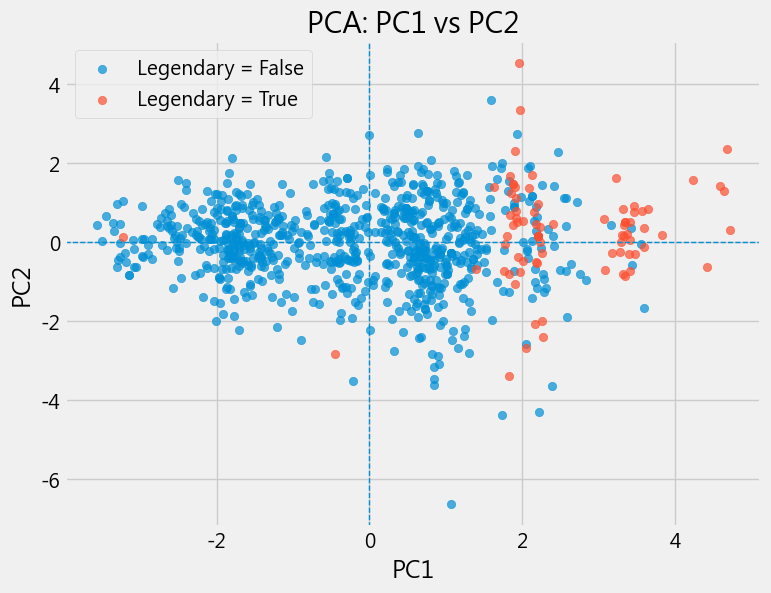

In [5]:
# ============================================================
# 3. PCA 視覺化：PC1 與 PC2
# ============================================================

plt.figure(figsize=(8, 6))

# Legendary 只用來輔助視覺化，不作為 PCA 的訓練目標。
for legendary_value in [False, True]:
    mask = (work["Legendary"] == legendary_value).to_numpy()  # 確保 mask 是 numpy 陣列
    plt.scatter(
        X_pca[mask, 0], # 0 代表 PC1
        X_pca[mask, 1], # 1 代表 PC2
        alpha=0.7,
        label="Legendary = " + str(legendary_value)
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2")
plt.legend()
plt.show()

## 4. Kernel PCA

一般 PCA 只能找線性的主成分方向。  
如果資料結構是彎曲、環狀、月牙形等非線性關係，可以使用 Kernel PCA 嘗試把資料映射到更高維空間，再進行降維。

這裡示範常見的 RBF kernel。

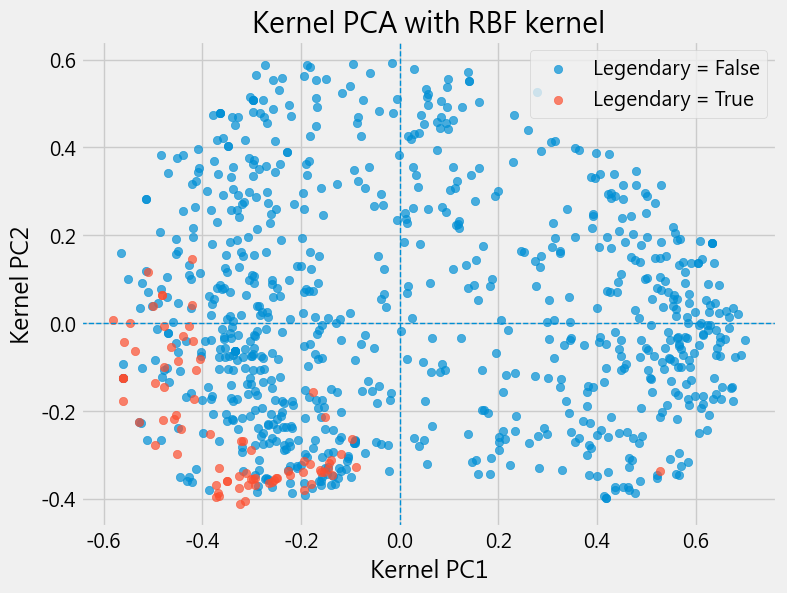

In [6]:
# ============================================================
# 4. Kernel PCA：使用 RBF kernel 做非線性降維
# ============================================================

from sklearn.decomposition import KernelPCA

kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.2
)

X_kpca = kpca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for legendary_value in [False, True]:
    mask = (work["Legendary"] == legendary_value).to_numpy()
    plt.scatter(
        X_kpca[mask, 0],
        X_kpca[mask, 1],
        alpha=0.7,
        label="Legendary = " + str(legendary_value)
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.title("Kernel PCA with RBF kernel")
plt.legend()
plt.show()

## 5. K-means 分群

K-means 會先指定群數 `K`，再反覆進行兩件事：

1. 將每筆資料分到最近的質心。
2. 重新計算每一群的質心。

這裡用 `n_clusters=4` 示範分群，也示範如何把新資料放入已訓練好的 K-means 模型進行分群預測。

另外，因為你希望每章至少看到 fold 訓練結果，這裡使用 `KFold` 搭配 K-means。  
注意：這不是監督式學習的正統模型評估，而是用來觀察「不同資料切分下，K-means 訓練結果是否穩定」。

In [7]:
# ============================================================
# 5. K-means：建立分群、預測新資料、檢視每個 fold 訓練結果
# ============================================================

from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=0
)

kmeans_labels = kmeans.fit_predict(X_scaled)

cluster_result = work[["Name", "Type1", "Legendary"]].copy()
cluster_result["KMeansCluster"] = kmeans_labels

print("每個 K-means 群集的資料筆數：")
display(cluster_result["KMeansCluster"].value_counts().sort_index().to_frame("count"))

print("\n每個群集中 Legendary 的比例：")
display(cluster_result.groupby("KMeansCluster")["Legendary"].mean().to_frame("Legendary ratio"))

# 欄位順序必須和 features 相同：
# ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]
newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]

newData_scaled = scaler.transform(newData)
newData_cluster = kmeans.predict(newData_scaled)

print("\n新資料的 K-means 分群結果：")
print(newData_cluster)

# 使用 KFold 檢視每個 fold 的 K-means 訓練結果。
kf = KFold(n_splits=5, shuffle=True, random_state=0)

fold_rows = []

for fold, result in enumerate(kf.split(X_scaled), start=1):
    train_index = result[0]

    fold_model = KMeans(
        n_clusters=4,
        n_init=10,
        random_state=0
    )

    fold_labels = fold_model.fit_predict(X_scaled[train_index])

    fold_rows.append({
        "fold": fold,
        "train_samples": len(train_index),
        "inertia": fold_model.inertia_,
        "silhouette": silhouette_score(X_scaled[train_index], fold_labels)
    })

print("\n每個 fold 的 K-means 訓練結果：")
display(pd.DataFrame(fold_rows))

每個 K-means 群集的資料筆數：


,count
KMeansCluster,
0,144
1,299
2,294
3,157



每個群集中 Legendary 的比例：


,Legendary ratio
KMeansCluster,
0,0.076389
1,0.003344
2,0.000000
3,0.426752



新資料的 K-means 分群結果：
[1 3]

每個 fold 的 K-means 訓練結果：


,fold,train_samples,inertia,silhouette
0,1,715,2279.019988,0.212264
1,2,715,2247.016205,0.235449
2,3,715,2338.175848,0.215026
3,4,715,2196.161656,0.224073
4,5,716,2354.250020,0.218063


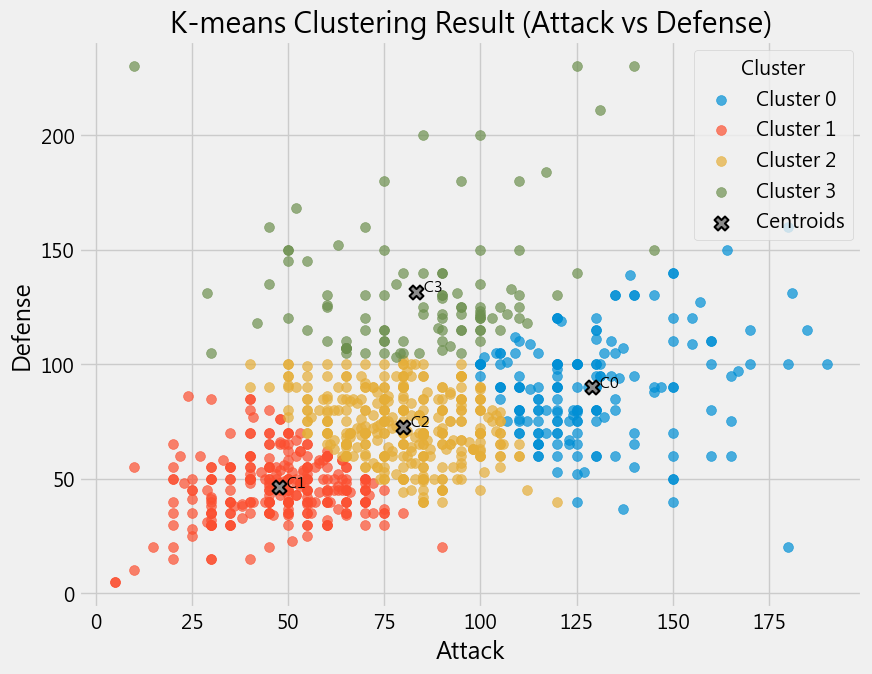

In [8]:
# ============================================================
# 5. K-means 2 維分群視覺化：資料點 + 群心
# ============================================================
#
# 說明：
#   這裡直接選擇兩個原始特徵作為 2 維分群空間，以便視覺化 K-means 的分群結果。
#   未來練習的時候，可以改成使用 PCA 的前兩個主成分作為 2 維分群空間，或是使用其他特徵組合。
#
#   圖中：
#       每個點  ：一筆資料
#       顏色    ：K-means 分到的群集
#       X 標記  ：每個群集的群心 centroid
#
# 注意：
#   K-means 對特徵尺度敏感，所以分群時使用標準化後的資料。
#   但為了讓圖比較容易理解，最後會把群心轉回原始尺度來畫圖。
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 5.1 指定要用來畫 2 維分群的兩個特徵
# ------------------------------------------------------------
feature_x = "Attack"
feature_y = "Defense"

selected_features = [feature_x, feature_y]

# ------------------------------------------------------------
# 5.2 取出 2 維資料
# ------------------------------------------------------------
X_2d = work[selected_features].copy()

# ------------------------------------------------------------
# 5.3 標準化 2 維資料
# ------------------------------------------------------------
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# ------------------------------------------------------------
# 5.4 建立並訓練 K-means 模型
# ------------------------------------------------------------
kmeans_2d = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=0
)

kmeans_2d_labels = kmeans_2d.fit_predict(X_2d_scaled)

# ------------------------------------------------------------
# 5.5 取得群心，並轉回原始尺度
# ------------------------------------------------------------
centers_scaled = kmeans_2d.cluster_centers_
centers_original = scaler_2d.inverse_transform(centers_scaled)

# ------------------------------------------------------------
# 5.6 視覺化 K-means 分群結果與群心
# ------------------------------------------------------------
plt.figure(figsize=(9, 7))

cluster_ids = sorted(set(kmeans_2d_labels))

for cluster_id in cluster_ids:
    cluster_points = X_2d[kmeans_2d_labels == cluster_id]

    plt.scatter(
        cluster_points[feature_x],
        cluster_points[feature_y],
        label=f"Cluster {cluster_id}",
        alpha=0.7,
        s=50
    )

# 畫出群心
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=100,
    edgecolors="black",
    linewidths=1.5,
    label="Centroids"
)

# 在群心旁邊標示 C0、C1、C2、C3
for cluster_id in range(len(centers_original)):
    center_x = centers_original[cluster_id, 0]
    center_y = centers_original[cluster_id, 1]

    plt.text(
        center_x,
        center_y,
        f"  C{cluster_id}",
        fontsize=11
    )

plt.title(f"K-means Clustering Result ({feature_x} vs {feature_y})")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

## 6. 評估 K-means 分群結果

K-means 常用兩種方式觀察分群品質：

1. **Distortion / Inertia / SSE**：每筆資料到自己群中心的距離平方和，通常越小越好，但 K 越大一定越小，所以不能只看它。
2. **Silhouette Score**：同時考慮群內距離與群間距離，越接近 1 通常越好。

Elbow Method 會觀察 `K` 增加時 inertia 下降的速度，找出下降幅度開始變慢的位置。

,K,Inertia,Silhouette Score
0,2,3670.080137,0.286775
1,3,3191.420323,0.252772
2,4,2862.866303,0.220976
3,5,2598.861263,0.226710
4,6,2429.412172,0.236986
5,7,2263.355054,0.230555
6,8,2154.317831,0.165299
7,9,2038.294076,0.165593


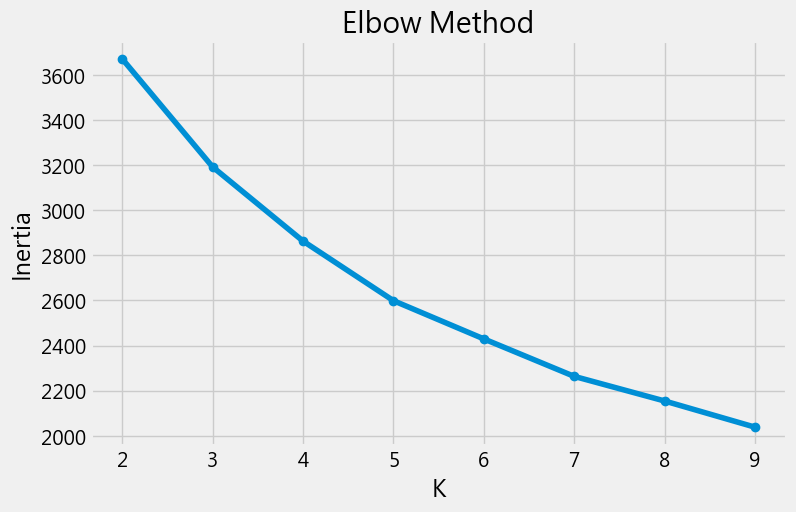

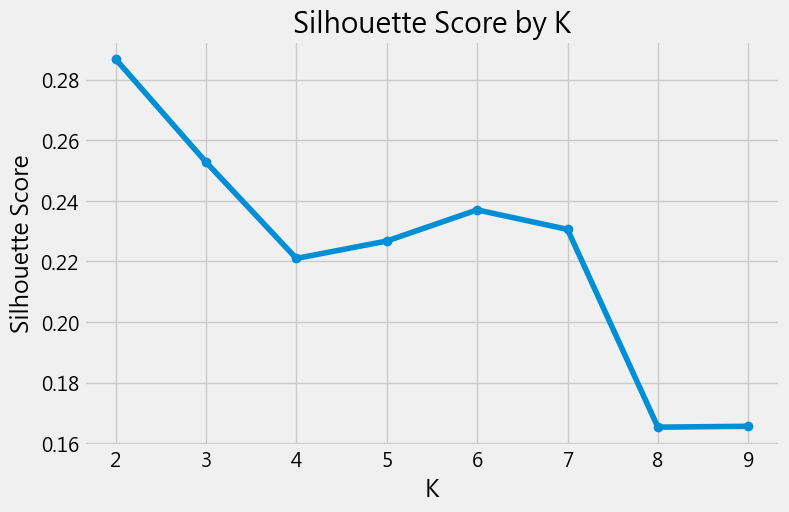

In [9]:
# ============================================================
# 6. K-means 評估：Elbow Method 與 Silhouette Score
# ============================================================

k_values = []
inertia_values = []
silhouette_values = []

for k in range(2, 10):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0
    )

    labels = model.fit_predict(X_scaled)

    k_values.append(k)
    inertia_values.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

kmeans_eval = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

display(kmeans_eval)


# ------------------------------------------------------------
# Elbow Method
# ------------------------------------------------------------
# Inertia 越小，代表群內資料越集中。
# 但是 K 越大，Inertia 幾乎一定會下降，
# 所以重點是觀察下降速度開始變慢的位置。

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")

plt.xticks(k_values)  # 讓 x 軸只顯示整數 K

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# ------------------------------------------------------------
# Silhouette Score
# ------------------------------------------------------------
# Silhouette Score 越高，通常代表分群效果越好。
# 它同時考慮：
#   1. 同一群內的資料是否接近
#   2. 不同群之間是否分開

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_values, marker="o")

plt.xticks(k_values)  # 讓 x 軸只顯示整數 K

plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.show()

## 7. 階層式分群

階層式分群會從樣本之間的距離建立樹狀結構。  
常見 linkage 方法包括：

- `single`：看兩群中最近的兩個點。
- `complete`：看兩群中最遠的兩個點。
- `average`：看兩群所有點距離的平均。
- `ward`：選擇讓群內變異增加最少的合併方式。

這裡會先比較不同 linkage 方法的分群結果，再用 `ward` 畫出一小部分資料的 dendrogram。

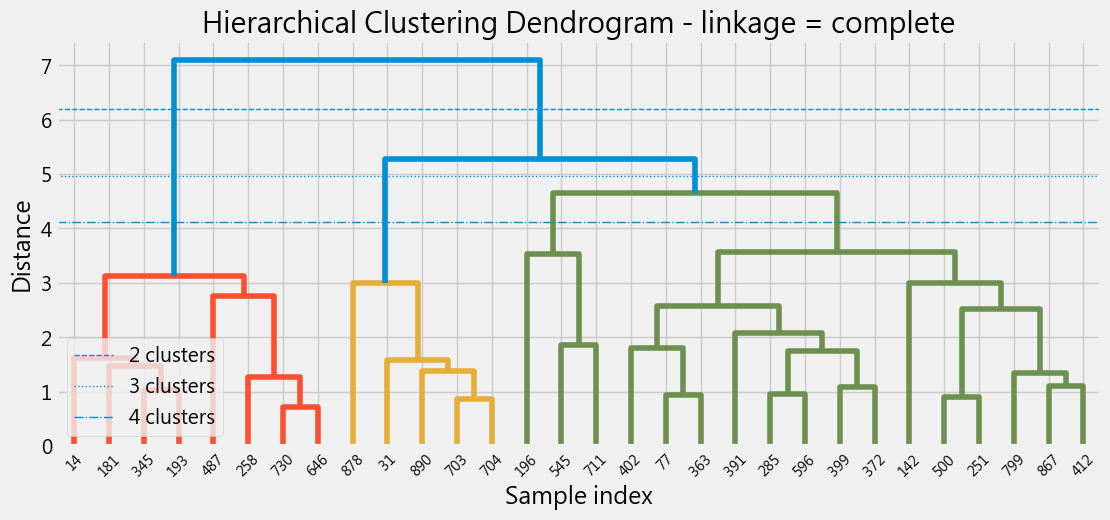

In [10]:
# ============================================================
# 7. 階層式分群：dendrogram 與群數切割線
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram

# ------------------------------------------------------------
# 7.1 設定 linkage 方法
# ------------------------------------------------------------
# 可以改成：
#   "single"
#   "complete"
#   "average"
#   "ward"

selected_linkage = "complete"


# ------------------------------------------------------------
# 7.2 抽樣部分資料畫 dendrogram
# ------------------------------------------------------------
# 如果資料太多，dendrogram 會很擁擠，
# 所以這裡只抽 40 筆示範。

sample_scaled = scaled_data.sample(n=30, random_state=0)


# ------------------------------------------------------------
# 7.3 建立階層式分群結果
# ------------------------------------------------------------
# linkage() 會記錄資料一步一步被合併的過程。
# dendrogram() 會根據這個結果畫出樹狀圖。

Z = linkage(
    sample_scaled.to_numpy(),
    method=selected_linkage
)

# ------------------------------------------------------------
# 7.4 計算切成 2 群、3 群時的參考高度
# ------------------------------------------------------------
# Z[:, 2] 是每一次合併時的距離。
# 距離越大，表示越後面才被合併。
#
# 若要切成 2 群：
#   橫線可以畫在最後一次合併距離與倒數第二次合併距離之間。
#
# 若要切成 3 群：
#   橫線可以畫在倒數第二次合併距離與倒數第三次合併距離之間。

distances = Z[:, 2]

height_for_2_clusters = (distances[-1] + distances[-2]) / 2
height_for_3_clusters = (distances[-2] + distances[-3]) / 2
height_for_4_clusters = (distances[-3] + distances[-4]) / 2


# ------------------------------------------------------------
# 7.5 繪製 dendrogram
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

dendrogram(
    Z,
    labels=sample_scaled.index.astype(str).tolist()
)

plt.title("Hierarchical Clustering Dendrogram - linkage = " + selected_linkage)
plt.xlabel("Sample index")
plt.ylabel("Distance")


# ------------------------------------------------------------
# 7.6 加上切割線
# ------------------------------------------------------------

plt.axhline(
    y=height_for_2_clusters,
    linestyle="--",
    linewidth=1,
    label="2 clusters"
)

plt.axhline(
    y=height_for_3_clusters,
    linestyle=":",
    linewidth=1,
    label="3 clusters"
)

plt.axhline(
    y=height_for_4_clusters,
    linestyle="-.",
    linewidth=1,
    label="4 clusters"
)


plt.legend()
plt.show()

## 8. DBSCAN 分群

DBSCAN 是密度式分群方法，不需要事先指定群數。  
它會根據兩個主要參數判斷群集與噪音點：

- `eps`：半徑，也就是多近才算鄰居。
- `min_samples`：半徑範圍內至少要有多少點，才可形成核心點。

注意：DBSCAN 對資料尺度與 `eps` 非常敏感。因此，建議先對資料進行 PCA 降維，再使用 DBSCAN 分群。


DBSCAN 分群結果前 5 筆：


,Attack,Defense,DBSCAN_label
0,49,49,0
1,62,63,0
2,82,83,0
3,100,123,0
4,52,43,0



各群集與噪音點的資料筆數：


,DBSCAN_label,count
0,-1,56
1,0,817
2,1,10
3,2,5
4,3,6


群集數量（不含噪音點）： 4
噪音點數量： 56


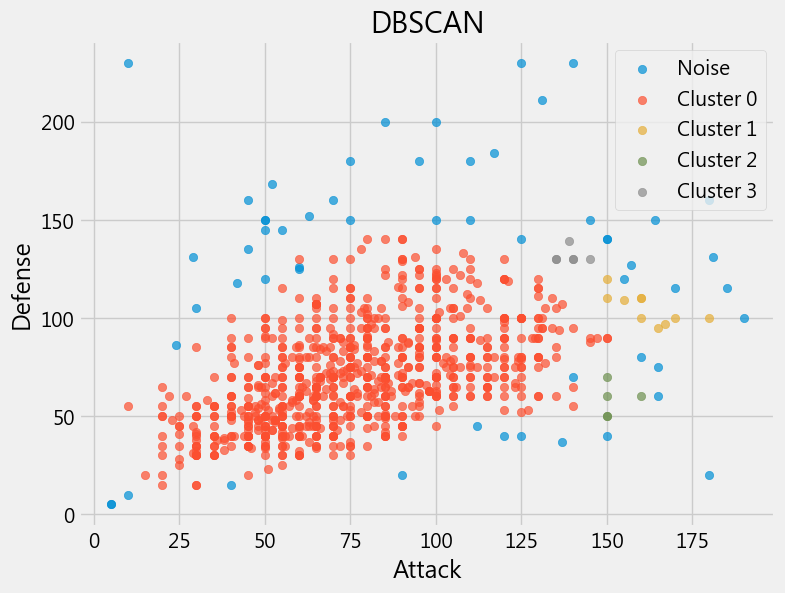

In [11]:
# ============================================================
# 9. DBSCAN：使用兩個原始特徵做密度式分群
# ============================================================

from sklearn.cluster import DBSCAN

# ------------------------------------------------------------
# 9.1 選擇兩個原始特徵
# ------------------------------------------------------------

dbscan_features = ["Attack", "Defense"]

X_dbscan = work[dbscan_features].copy()

# ------------------------------------------------------------
# 9.2 建立 DBSCAN 模型
# ------------------------------------------------------------
# eps：
#   鄰近範圍的半徑。
#   eps 越大，越容易把資料點合併成同一群。
#
# min_samples：
#   一個區域內至少要有多少個點，才會被視為高密度區域。
#
# label 的意義：
#   -1：噪音點
#    0：第 0 群
#    1：第 1 群
#    2：第 2 群
#    ...

dbscan = DBSCAN(
    eps=10,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_dbscan)

# ------------------------------------------------------------
# 9.3 將分群結果整理成表格
# ------------------------------------------------------------

dbscan_result = X_dbscan.copy()
dbscan_result["DBSCAN_label"] = dbscan_labels

print("DBSCAN 分群結果前 5 筆：")
display(dbscan_result.head())

# ------------------------------------------------------------
# 9.4 統計每一個 label 的資料筆數
# ------------------------------------------------------------

label_summary = (
    dbscan_result["DBSCAN_label"]
    .value_counts()
    .sort_index()
    .reset_index()
)

label_summary.columns = ["DBSCAN_label", "count"]

print("\n各群集與噪音點的資料筆數：")
display(label_summary)

# ------------------------------------------------------------
# 9.5 計算群集數量與噪音點數量
# ------------------------------------------------------------

cluster_count = 0

for label in sorted(dbscan_result["DBSCAN_label"].unique()):
    if label != -1:
        cluster_count = cluster_count + 1

noise_count = 0

for label in dbscan_result["DBSCAN_label"]:
    if label == -1:
        noise_count = noise_count + 1

print("群集數量（不含噪音點）：", cluster_count)
print("噪音點數量：", noise_count)

# ------------------------------------------------------------
# 9.6 視覺化 DBSCAN 分群結果
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for label in sorted(dbscan_result["DBSCAN_label"].unique()):

    mask = dbscan_result["DBSCAN_label"] == label

    if label == -1:
        label_name = "Noise"
    else:
        label_name = "Cluster " + str(label)

    plt.scatter(
        dbscan_result.loc[mask, "Attack"],
        dbscan_result.loc[mask, "Defense"],
        alpha=0.7,
        label=label_name
    )

plt.xlabel("Attack")
plt.ylabel("Defense")
plt.title("DBSCAN")
plt.legend()
plt.show()